# Creating Combined Embedding Layer
Reducing audio and lyric embeddings with PCA and merging through simple concatenation.

In [2]:
import numpy as np
import pandas as pd

#import parquet file from hugging face as dataframe
df = pd.read_parquet("hf://datasets/vectors2vibes/vectors2vibes-discogs-metadata/data/master_dataset.parquet")

In [5]:
#data inspection
df.info()
df['audio_embedding'].isna().value_counts()
df['lyric_embeddings'].isna().value_counts()
df[df['earliest_release'].isna()]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24684 entries, 0 to 24683
Data columns (total 29 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    24684 non-null  object 
 1   file_path             24684 non-null  object 
 2   version_id            22625 non-null  object 
 3   release_id            24684 non-null  float64
 4   master_id             18311 non-null  float64
 5   track_title           24684 non-null  object 
 6   earliest_release      24677 non-null  float64
 7   discogs_released      21244 non-null  float64
 8   release_artist_names  24684 non-null  object 
 9   release_title         24684 non-null  object 
 10  release_genres        24684 non-null  object 
 11  release_styles        20600 non-null  object 
 12  country               24306 non-null  object 
 13  labels                24684 non-null  object 
 14  duration              24684 non-null  int64  
 15  youtube_video      

,id,file_path,version_id,release_id,master_id,track_title,earliest_release,discogs_released,release_artist_names,release_title,...,source_corpus,ingest_batch,audio_embedding,lyric_embeddings,transcribed_lyrics,lyric_language,whisper_fallback,vad_speech_fraction,combined_embedding,embedding_type
18095,Y0mVwcHP8OQ,Y0/Y0mVwcHP8OQ.ogg,V-0577385,15354221.0,NaN,Singin' The Blues,NaN,1921.0,"[""Carl Fenton's Orchestra"", ""Bennie Krueger's ...",Kiss A Miss / Singin' The Blues,...,Discogs-VI-YT-20240701,20260304-audio-batch,"[0.0025537454, 0.063070856, -0.030305259, 0.02...","[-0.022318627685308456, 0.05560745671391487, 0...",You You You You You You You,en,True,0.0000,"[-0.40102500801573876, 0.36564954120178633, 0....",audio+lyric
18781,xunZiN7vNzw,xu/xunZiN7vNzw.ogg,V-1109841,4909242.0,NaN,Caruso,NaN,2008.0,"['Petra Berger', 'Jan Vayne']",Crystal,...,Discogs-VI-YT-20240701,20260304-audio-batch,"[-0.0032143607, 0.062416784, -0.038807, 0.0097...","[-0.002891496755182743, 0.005599865689873695, ...","Te vol jo benia sai, m'atanto, tanto benia sai...",ca,False,0.2091,"[-0.5300142388663008, 0.20158542225228754, 0.2...",audio+lyric
20977,Q8mswcI8glw,Q8/Q8mswcI8glw.ogg,V-1107009,30516661.0,1816084.0,Don't Bring Lulu,NaN,1925.0,"[""Bennie Krueger's Orchestra""]",Yearning / Don't Bring Lulu,...,Discogs-VI-YT-20240701,20260304-audio-batch,"[-0.031528153, 0.096241094, -0.06878643, -0.07...","[-0.04244176670908928, 0.026578126475214958, 0...","our and i I You can bring pearls, he's a darn ...",en,False,0.0181,"[-0.37675631520857483, 0.41997513961480226, 0....",audio+lyric
22742,fbTvTHpv-AY,fb/fbTvTHpv-AY.ogg,None,18824767.0,2320675.0,Ameline,NaN,2021.0,['Deidian'],Equinox,...,xml_discogs_meta,20260331-audio-batch,"[0.0162502434104681, 0.09030640125274658, -0.0...","[0.0018967324867844582, 0.07341298460960388, -...",� quarter m � illegally ས ཯ཅཚདྷོུཬ཰ོསོོ་ླྀལོཿོ཰ོ...,km,True,0.0000,"[0.37647758630938627, -0.08526063798516942, -0...",audio+lyric
22900,DstSIq1Xb7U,Ds/DstSIq1Xb7U.ogg,None,31748747.0,3599300.0,Σκάρτος,NaN,2018.0,"[""Ψύλλοι Στ' Άχυρα""]",Ψύλλοι Στ' Άχυρα,...,xml_discogs_meta,20260331-audio-batch,"[0.05337557941675186, 0.10002554208040237, -0....","[-0.024660859256982803, -0.03831583634018898, ...","A dari ay I am vaan Am ACE A Irish, I'm grown ...",en,False,0.1954,"[0.5872462633877273, 0.07317890273396754, -0.1...",audio+lyric
22955,fJtmRj-Z94s,fJ/fJtmRj-Z94s.ogg,None,11861919.0,4141927.0,Surilang,NaN,2002.0,['Snada'],SNADA Album Dari Jakarta Ke Kuala Lumpur S...,...,xml_discogs_meta,20260331-audio-batch,"[0.041017353534698486, 0.03548377752304077, -0...","[-0.06510162353515625, 0.08089622855186462, 0....",Intro Suri langjut-ngjutan Ada ujan rintik per...,id,True,0.4049,"[0.08684957725205115, 0.36620706719287616, -0....",audio+lyric
24346,b4L_tpRCt7Y,b4/b4L_tpRCt7Y.ogg,None,30126104.0,3428993.0,TxSxGxC,NaN,2022.0,['Kombaat'],Kombaatologie,...,xml_discogs_meta,20260331-audio-batch,"[0.05085145682096481, 0.04586237668991089, -0....","[-0.07708513736724854, 0.10044587403535843, -0...","Okay, jetzt gibt's so much gentlemen like, was...",de,False,0.7297,"[0.5945506241903159, 0.08814034886295569, -0.1...",audio+lyric


Null values found in 'earliest_release' column (year of release proxy)--these were dealt with on the server side.

In [8]:
# some songs don't have any lyrics and thus have only zero values for lyirc embeddings; we want to keep track of this for combining and normalizing embeddings
audio_matrix = np.array(df["audio_embedding"].tolist())

lyric_mask = df["lyric_embeddings"].apply(lambda x: not np.all(np.array(x) == 0))
lyric_indices = df.index[lyric_mask].tolist()
audio_only_indices = df.index[~lyric_mask].tolist()
lyric_matrix = np.array(df.loc[lyric_mask, "lyric_embeddings"].tolist())

print(f"songs with audio only: {(~lyric_mask).sum()}")
print(f"songs with audio + lyrics: {lyric_mask.sum()}")

songs with audio only: 964
songs with audio + lyrics: 23720


In [10]:
print(len(df), len(audio_matrix), len(lyric_matrix))

24684 24684 23720


In [8]:
df.columns

Index(['id', 'file_path', 'version_id', 'release_id', 'master_id',
       'track_title', 'earliest_release', 'discogs_released',
       'release_artist_names', 'release_title', 'release_genres',
       'release_styles', 'country', 'labels', 'duration', 'youtube_video',
       'webpage_url', 'thumbnail', 'thumbnail_path', 'source_corpus',
       'ingest_batch', 'audio_embedding', 'lyric_embeddings',
       'transcribed_lyrics', 'lyric_language', 'whisper_fallback',
       'vad_speech_fraction', 'combined_embedding', 'embedding_type'],
      dtype='object')

Audio (wav2vec): 112 components explain 95.0% of variance


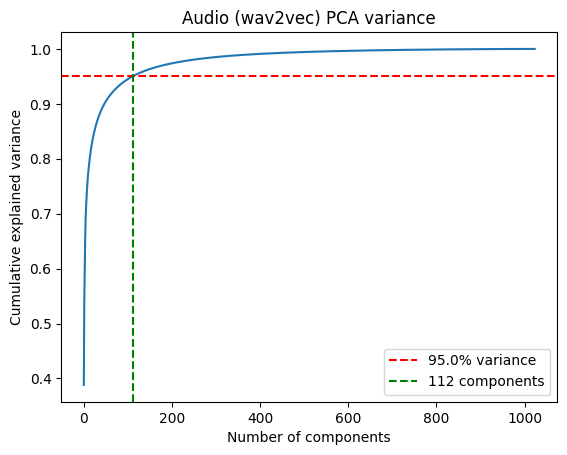

Lyric (Whisper): 244 components explain 95.0% of variance


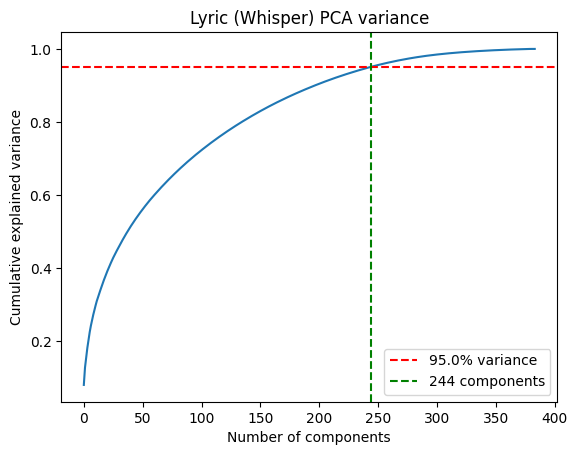

In [11]:
#finding best target dimensions for PCA reduction
#import libraries
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

def plot_explained_variance(matrix, name, threshold=0.95):
    """
    Find and plot the number of components needed to explain 95% of variance in an embedding matrix.
    """
    #instantiate model
    pca = PCA()
    pca.fit(matrix)
    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

    n_components = np.argmax(cumulative_variance >= threshold) + 1
    print(f"{name}: {n_components} components explain {threshold*100}% of variance")

    plt.plot(cumulative_variance)
    plt.axhline(y=threshold, color='r', linestyle='--', label=f'{threshold*100}% variance')
    plt.axvline(x=n_components, color='g', linestyle='--', label=f'{n_components} components')
    plt.xlabel("Number of components")
    plt.ylabel("Cumulative explained variance")
    plt.title(f"{name} PCA variance")
    plt.legend()
    plt.show()

plot_explained_variance(audio_matrix, "Audio (wav2vec)")
plot_explained_variance(lyric_matrix, "Lyric (Whisper)")

112 and 244 are minimum target dimensions for PCA reduction for audio and lyric embedding matrices, respectively.

In [ ]:
#reducing dimensionality before merging embeddings
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
from tqdm.notebook import tqdm

#implement progress bar
with tqdm(total=4, desc="Building combined embeddings") as pbar:

    #audio and lyric embeddings are reduced to the same dimensions so that they contribute equally to the merged embeddings
    pbar.set_description("Reducing audio embeddings (PCA: 1024 → 256 dims)")
    pca_audio = PCA(n_components=256)
    audio_reduced = normalize(pca_audio.fit_transform(audio_matrix))
    pbar.update(1)

    pbar.set_description("Reducing lyric embeddings (PCA: 388 → 256 dims)")
    pca_lyric = PCA(n_components=256)
    lyric_reduced = normalize(pca_lyric.fit_transform(lyric_matrix))
    pbar.update(1)

    pbar.set_description("Combining embeddings (512 dims)")
    #Initialize 'combined' with the length of df, as audio_reduced and lyric_reduced are based on df_copy
    combined = np.zeros((len(df), 512))
    combined[:, :256] = audio_reduced          # audio dims for all songs
    # lyric_indices also comes from df, so it aligns with combined's new size
    combined[lyric_indices, 256:] = lyric_reduced  # lyric dims only for songs with lyrics
    pbar.update(1)

    pbar.set_description("Normalising and writing back to dataframe")
    combined = normalize(combined)
    # Assign new columns to df_copy for consistency
    df_copy["combined_embedding"] = list(combined)
    # lyric_mask also comes from df_copy
    df_copy["embedding_type"] = lyric_mask.apply(lambda x: "audio+lyric" if x else "audio_only")
    pbar.update(1)

# --- Build embeddings matrix for cosine similarity ---
combined_matrix = np.array(df["combined_embedding"].tolist())

In [13]:
#creating sub-dataframe for quick inspection
columns = ['id', 'track_title', 'earliest_release', 'release_artist_names', 'release_genres', 'transcribed_lyrics', 'lyric_language', 'audio_embedding', 'lyric_embeddings', 'combined_embedding', 'embedding_type', 'webpage_url']
df_selection = df[columns]
df_selection.head()

,id,track_title,earliest_release,release_artist_names,release_genres,transcribed_lyrics,lyric_language,audio_embedding,lyric_embeddings,combined_embedding,embedding_type,webpage_url
0,sZSpQwL2nks,In The Mood,1983.0,"['The Glenn Miller Orchestra', 'Buddy DeFranco']",['Jazz'],Third 🎵,en,"[-0.016071385, 0.01969921, -0.034265433, 0.003...","[-0.017627323046326637, -0.08944163471460342, ...","[0.2042229575000474, 0.030878279911066103, -0....",audio+lyric,https://www.youtube.com/watch?v=sZSpQwL2nks
1,sZVXgac7Pcc,Stella By Starlight,1979.0,"['Joe Temperley', 'Jimmy Knepper']",['Jazz'],"[""Pomp and Circumstance""] [""Pomp and Circumsta...",en,"[-0.02416538, 0.04806304, -0.019728804, -0.024...","[0.017654601484537125, 0.0622858926653862, -0....","[-0.43029987334177233, 0.028641018969980392, -...",audio+lyric,https://www.youtube.com/watch?v=sZVXgac7Pcc
2,GSdiOrZmmis,Flying Home,1960.0,"['The Ronnie Scott Orchestra', 'Tony Crombie']",['Jazz'],СПОКОЙНАЯ МУЗЫКА МУЗЫКАЛЬНАЯ ЗАСТАВКА МУЗЫКАЛЬ...,ru,"[0.022540206, 0.12783284, 0.007165747, 0.02008...","[0.04377881437540054, 0.06300900876522064, -0....","[0.35076431923805323, 0.2822065761043356, 0.11...",audio+lyric,https://www.youtube.com/watch?v=GSdiOrZmmis
3,GStHifqUKWI,God's Gift To The World,1973.0,['Ted Neeley'],['Rock'],"Music This one, that one, each one is God's gi...",en,"[0.035077836, 0.044757698, -0.004790673, 0.039...","[-0.025458218529820442, 0.030138444155454636, ...","[0.17349409924981243, 0.33962427704695614, 0.0...",audio+lyric,https://www.youtube.com/watch?v=GStHifqUKWI
4,GSRdJ5Dqd4A,El Violin De Becho,1965.0,"['Maria Dolores Pradera', 'Los Gemelos']",['Latin'],¡Veche o toque el violín en la orquesta! Carab...,es,"[-0.0048006778, 0.08648973, -0.0005897561, 0.0...","[-0.02893192321062088, -0.029728999361395836, ...","[-0.41215095222285153, -0.07327014827430846, 0...",audio+lyric,https://www.youtube.com/watch?v=GSRdJ5Dqd4A


In [15]:
df_selection.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24684 entries, 0 to 24683
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    24684 non-null  object 
 1   track_title           24684 non-null  object 
 2   earliest_release      24677 non-null  float64
 3   release_artist_names  24684 non-null  object 
 4   release_genres        24684 non-null  object 
 5   transcribed_lyrics    24684 non-null  object 
 6   lyric_language        24684 non-null  object 
 7   audio_embedding       24684 non-null  object 
 8   lyric_embeddings      24684 non-null  object 
 9   combined_embedding    24684 non-null  object 
 10  embedding_type        24684 non-null  object 
 11  webpage_url           24684 non-null  object 
dtypes: float64(1), object(11)
memory usage: 2.3+ MB


In [17]:
#create a new column 'is_jazz' in df_selection if string 'Jazz' is in 'release_genres'
df_selection['is_jazz'] = df_selection['release_genres'].apply(lambda x: 1 if 'Jazz' in x else 0)

/tmp/ipykernel_1038/3691835362.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selection['is_jazz'] = df_selection['release_genres'].apply(lambda x: 1 if 'Jazz' in x else 0)


In [18]:
df_selection['is_jazz'].value_counts()

,count
is_jazz,
0,15284
1,9400


In [ ]:
import umap
import matplotlib.pyplot as plt

reducer = umap.UMAP(n_components = 2, metric='cosine', random_state = 42) #instantiate UMAP model for a 2-D projection based on cosine similarity.
projected = reducer.fit_transform(combined)

plt.figure(figsize=(10,8))
plt.scatter(projected[:, 0], projected[:, 1], s=5, alpha=0.7, c=df_selection['earliest_release'])
plt.title("UMAP Projection colored by year of release")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.colorbar(label='Year of Release') # Add a colorbar to explain the colors
plt.show()

In [ ]:
plt.clf()

reducer = umap.UMAP(n_components = 2, metric='cosine', random_state = 42)
projected = reducer.fit_transform(combined)

plt.figure(figsize=(10,8))
plt.scatter(projected[:, 0], projected[:, 1], s=5, alpha=0.7, c=df_selection['is_jazz'], cmap='viridis')
plt.title("UMAP Projection colored by Jazz genre")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.colorbar(label='Is Jazz (0=No, 1=Yes)') # Add a colorbar to explain the colors
plt.show()

In [ ]:
#saving combined embeddings matrix
combined_matrix = np.array(df["combined_embedding"].tolist())
np.save("combined_embeddings_matrix_final.npy", combined_matrix)

# Writing new embeddings to Hugging Face parquet file

In [ ]:
# Install necessary libraries
!pip install datasets huggingface_hub --quiet

In [ ]:
# Log in to Hugging Face Hub for writing new columns to parquet file
from huggingface_hub import notebook_login

notebook_login()

Next, converting `df_merged` DataFrame to a Hugging Face `Dataset` object. Since the `combined_embedding` column contains list-like objects (numpy arrays), it will be saved as a sequence of floats.

In [ ]:
from datasets import Dataset

#Convert the pandas DataFrame to a Hugging Face Dataset
hf_dataset = Dataset.from_pandas(df_merged)

#check the dataset structure
print(hf_dataset)

Pushing dataset to the Hugging Face Hub. You'll need to specify your Hugging Face username and a repository name. If the repository doesn't exist, it will be created.

In [ ]:
# Replace 'your_username' and 'your-repo-name' with your actual Hugging Face username and desired repository name
repo_id = "vectors2vibes/vectors2vibes-discogs-metadata"

hf_dataset.push_to_hub(repo_id)

print(f"Dataset successfully pushed to https://huggingface.co/datasets/{repo_id}")